In [11]:
%load_ext autoreload
%autoreload 2
import json
import sciexplorer
from sciexplorer.utils.print_utils import whole_conversation_to_string, print_whole_conversation, print_message, print_result
# set model type
sciexplorer.utils.model_specifics.MODEL_TYPE = "openai"  # or "gemini"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# load results from a previous run
with open('./example_results/all_2025-12-08_16-30-51.json', 'r') as f:
    res = json.load(f)

In [13]:
# print a single message
print_message(res['messages'][9])

AI REASONING: **Preparing for visualization**

I’m planning to visualize using a time series and phase portrait. First, I need to explain my expectations and reasoning before I use the tools. I want to create a code that plots the time series for a couple of variables and overlays the phase plane. I also think about computing the derivatives numerically to inform my model. However, I should focus on plotting first, so I’ll call `plot_from_code` with multiple subplots for all initial conditions. Let's get started!
AI TEXT: I want to visualize the simulated trajectories to understand qualitative behavior: whether populations oscillate, converge to a fixed point, or show predator–prey cycles. Phase-plane plots from multiple initial conditions can reveal nullclines and equilibria structure. I expect to see whether trajectories approach a common point or a closed orbit, guiding the model class to test next. Now I’ll plot time series for a couple of runs and a phase portrait overlaying all r

SYSTEM TEXT: You are a cautious and curious scientist.
You visualize your data and results before fitting.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>

HUMAN TEXT: 
In this system, you can observe the population dynamics of two species in an experimental biological system.
Figure out the equations of motion governing the dynamics of this system.
Each tool has a maximum runtime of 300 seconds and is automatically terminated if it exceeds this limit.
The results of all tool calls will be stored (using the result_label) and are available later.
You have 5 steps remaining and can still call up to 18 tools.
Go on exploring the system or save your result if you cannot improve it anymore.

AI TEXT: Plan: I’ll start by observing the dynamics from several diverse initial conditions to see qualitatively what kinds of trajectories the system exhibits (e.g., oscillations, approach to equilibrium, divergence

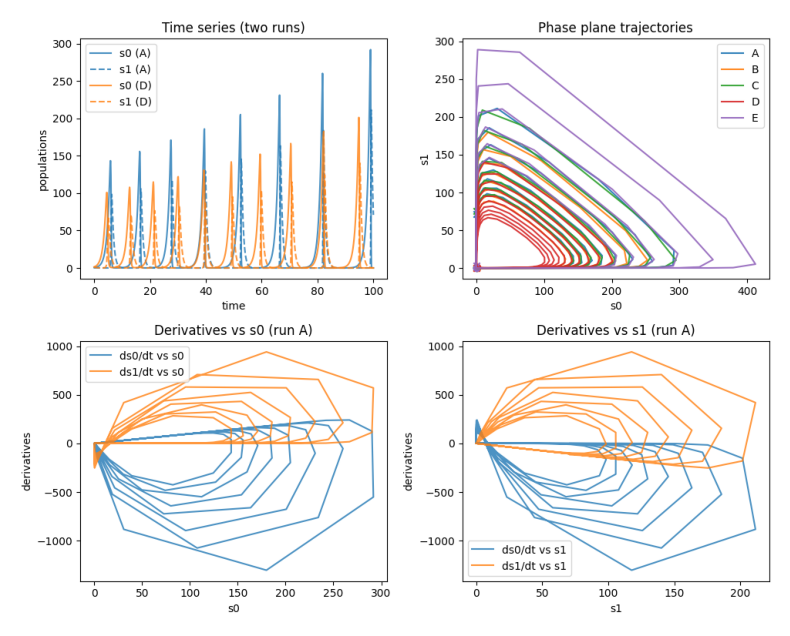


HUMAN TEXT: You have 3 steps remaining and can still call up to 12 tools.
Go on exploring the system or save your result if you cannot improve it anymore.

AI TEXT: I want to fit a biologically plausible predator–prey model to the observed vector field. The trajectories suggest relaxation oscillations consistent with a Rosenzweig–MacArthur model (logistic prey growth with Holling type II predation). I will estimate numerical derivatives from multiple runs and use nonlinear least squares to fit parameters r, K, a, h, e, m. I expect to recover parameters that reproduce the sharp predator spikes and low troughs. Now I’ll perform the fitting.
AI FUNCTION CALL: execute_code
  ARGUMENT code:
    import numpy as np
    from scipy.optimize import least_squares
    
    # Gather data from all runs
    runs = [(A_states, A_times), (B_states, B_times), (C_states, C_times), (D_states, D_times), (E_states, E_times)]
    Xs = []
    Ys = []
    for S, T in runs:
        # numerical derivatives usin

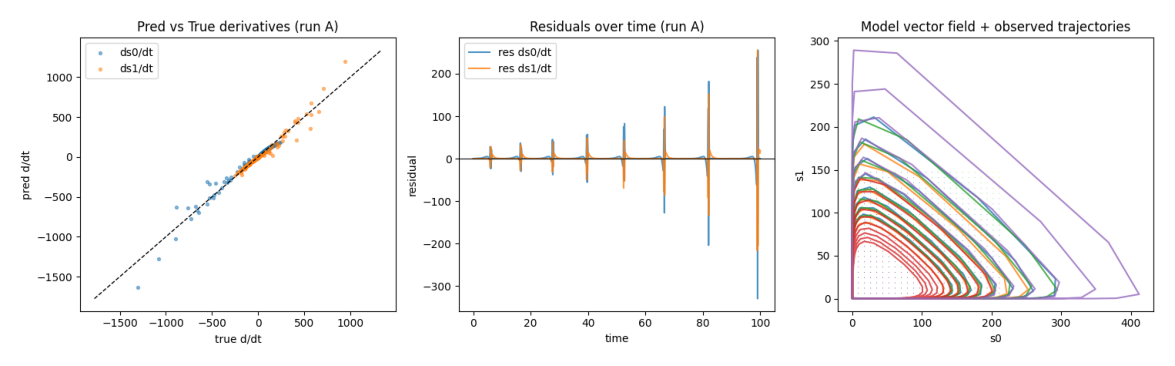


HUMAN TEXT: You have 1 steps remaining and can still call up to 10 tools.
Go on exploring the system or save your result if you cannot improve it anymore.

AI TEXT: I will now save the final inferred equations of motion so they can be evaluated by the system. Based on the visualized trajectories and the fit, a Rosenzweig–MacArthur predator–prey model with logistic prey growth and Holling type II predation matches the observed dynamics. I’ll save the equation using the fitted parameters. I expect this to reproduce the relaxation oscillations and vector field we validated.
AI FUNCTION CALL: save_result
  ARGUMENT result:
    import numpy as np
    
    def equation_of_motion(state: np.ndarray) -> np.ndarray:
        # Rosenzweig–MacArthur predator–prey model (Holling type II)
        # state = [x, y] where x = prey, y = predator
        x, y = state
        # Fitted parameters (from least squares on observed vector field)
        r = 1.18115246         # prey intrinsic growth rate
     

In [14]:
# print the whole conversation (excluding reasoning steps and showing images)
print_whole_conversation(res['messages'], to_exclude=[('AI', 'REASONING')], show_images=True)

In [15]:
# get a string representation of the whole conversation and base 64-encoded images
conversation_str, images = whole_conversation_to_string(res['messages'], to_exclude=[('AI', 'REASONING'),])
print(conversation_str)

SYSTEM TEXT: You are a cautious and curious scientist.
You visualize your data and results before fitting.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>

HUMAN TEXT: 
In this system, you can observe the population dynamics of two species in an experimental biological system.
Figure out the equations of motion governing the dynamics of this system.
Each tool has a maximum runtime of 300 seconds and is automatically terminated if it exceeds this limit.
The results of all tool calls will be stored (using the result_label) and are available later.
You have 5 steps remaining and can still call up to 18 tools.
Go on exploring the system or save your result if you cannot improve it anymore.

AI TEXT: Plan: I’ll start by observing the dynamics from several diverse initial conditions to see qualitatively what kinds of trajectories the system exhibits (e.g., oscillations, approach to equilibrium, divergence

In [17]:
print_result(res['result'])

import numpy as np

def equation_of_motion(state: np.ndarray) -> np.ndarray:
    # Rosenzweig–MacArthur predator–prey model (Holling type II)
    # state = [x, y] where x = prey, y = predator
    x, y = state
    # Fitted parameters (from least squares on observed vector field)
    r = 1.18115246         # prey intrinsic growth rate
    K = 675.053803         # prey carrying capacity
    a = 0.105627556        # predator attack rate
    h = 0.0131272382       # handling time
    e = 0.757908399        # conversion efficiency
    m = 1.36230061         # predator mortality rate

    # Functional response (Holling type II)
    func = (a * x) / (1.0 + a * h * x)

    dxdt = r * x * (1.0 - x / K) - func * y
    dydt = e * func * y - m * y
    return np.array([dxdt, dydt])
